# Predicting Sales Prices

 ## Dataset Attributes

 The dataset contains information about houses in Ames, Iowa. The data was collected by the Ames City Assessor’s Office describing 2930 property sales which occurred in Ames, Iowa between 2006 and 2010. The dataset, containing 81 variables, was compiled and published by De Cock in 2011.

 Some of the variables contained in the original dataset have been removed from the the dataset provided to you.
 The dataset provided to you contains the following variables:
* **Year_Built:** year that the house was originally constructed
* **Year_Remod_Add:** year that the house was last remodelled
* **Total_Bsmt_SF:** total size of basement area in square feet
* **First_Flr_SF:** size of the first floor in square feet
* **Second_Flr_SF:** size of the second floor in square feet
* **Gr_Liv_Area:** size of above grade, ground living area in square feet
* **Full_Bath:** number of full above grade bathrooms in the house
* **Half_Bath:** number of half above grade bathrooms in the house
* **Bedroom_AbvGr:** number of above grade bedrooms (does not include basement bedrooms)
* **Kitchen_AbvGr:** number of above grade kitchens
* **TotRms_AbvGrd:** total number of above grade rooms (does not include bathrooms)
* **Fireplaces:** number of fireplaces in the house
* **Garage_Area:** size of garage in square feet
* **Sale_Price:** sale price of the house in dollars


*De Cock, D. (2011). "Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester
Regression Project," Journal of Statistics Education, Volume 19, Number 3.*

- https://ww2.amstat.org/publications/jse/v19n3/decock/DataDocumentation.txt
- http://ww2.amstat.org/publications/jse/v19n3/decock.pdf


 ## Objective

 The goal of this task is to analyse the relationship between these variables and build a multiple linear regression model to predict the sales prices based on the 'Gr_Liv_Area' and 'Garage_Area` variables.


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
# Read in the data set
df = pd.read_csv('ames.csv')
# Display the first few rows of the data set
df.head()

,Year_Built,Year_Remod_Add,Total_Bsmt_SF,First_Flr_SF,Second_Flr_SF,Gr_Liv_Area,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,TotRms_AbvGrd,Fireplaces,Garage_Area,Sale_Price
0,1960,1960,1080,1656,0,1656,1,0,3,1,7,2,528,215000
1,1961,1961,882,896,0,896,1,0,2,1,5,0,730,105000
2,1958,1958,1329,1329,0,1329,1,1,3,1,6,0,312,172000
3,1968,1968,2110,2110,0,2110,2,1,3,1,8,2,522,244000
4,1997,1998,928,928,701,1629,2,1,3,1,6,1,482,189900


In [6]:
# Clean and pre-process the data if neccessary
print(df.info())
print(df.describe())

# Check for missing values
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Year_Built      2930 non-null   int64
 1   Year_Remod_Add  2930 non-null   int64
 2   Total_Bsmt_SF   2930 non-null   int64
 3   First_Flr_SF    2930 non-null   int64
 4   Second_Flr_SF   2930 non-null   int64
 5   Gr_Liv_Area     2930 non-null   int64
 6   Full_Bath       2930 non-null   int64
 7   Half_Bath       2930 non-null   int64
 8   Bedroom_AbvGr   2930 non-null   int64
 9   Kitchen_AbvGr   2930 non-null   int64
 10  TotRms_AbvGrd   2930 non-null   int64
 11  Fireplaces      2930 non-null   int64
 12  Garage_Area     2930 non-null   int64
 13  Sale_Price      2930 non-null   int64
dtypes: int64(14)
memory usage: 320.6 KB
None
        Year_Built  Year_Remod_Add  Total_Bsmt_SF  First_Flr_SF  \
count  2930.000000     2930.000000    2930.000000   2930.000000   
mean   1971.356314     1984.266553  

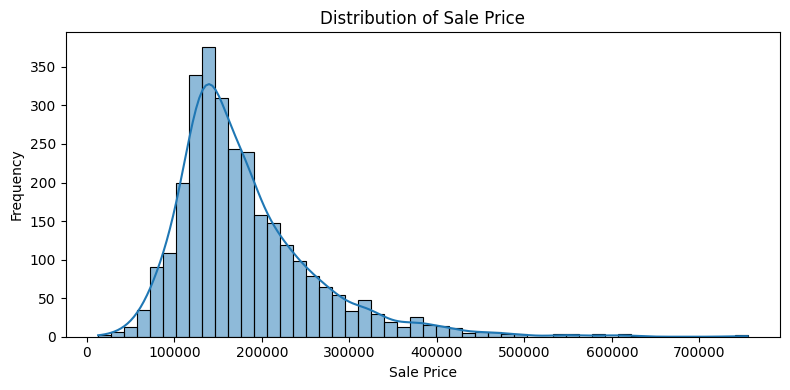

In [7]:
# Explore the data with visualisations such as histograms and correlation matrices
# Distribution of Sale Price
plt.figure(figsize=(8, 4))
sns.histplot(df['Sale_Price'], bins=50, kde=True)
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

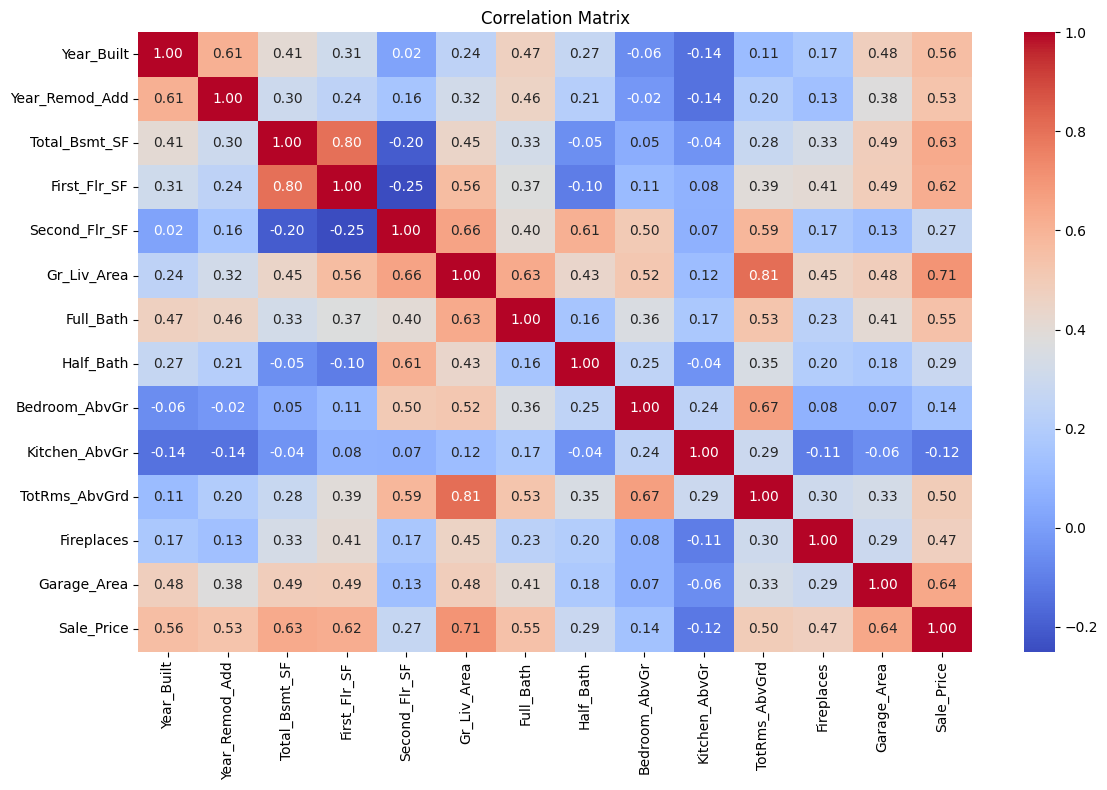

In [8]:
# Correlation matrix heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [9]:
# Split the independent variables from the dependent variable
X = df[['Gr_Liv_Area', 'Garage_Area']]
y = df['Sale_Price']

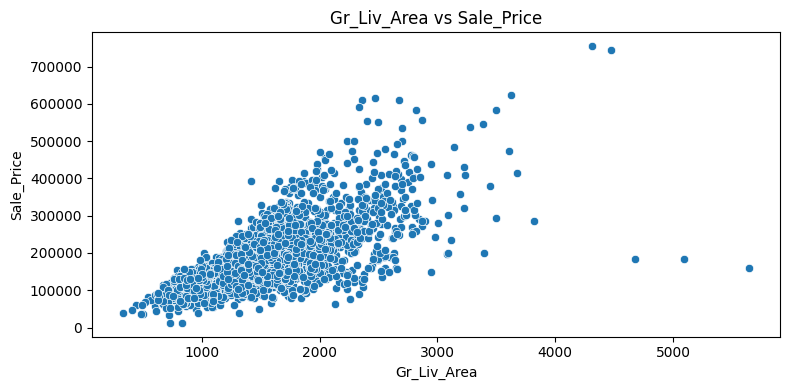

In [11]:
# Generate plots to explore the relationships between the independent and dependent variables
# Scatter plot of Gr_Liv_Area vs Sale_Price
plt.figure(figsize=(8, 4))
sns.scatterplot(x='Gr_Liv_Area', y='Sale_Price', data=df)
plt.title('Gr_Liv_Area vs Sale_Price')
plt.xlabel('Gr_Liv_Area')
plt.ylabel('Sale_Price')
plt.tight_layout()
plt.show()


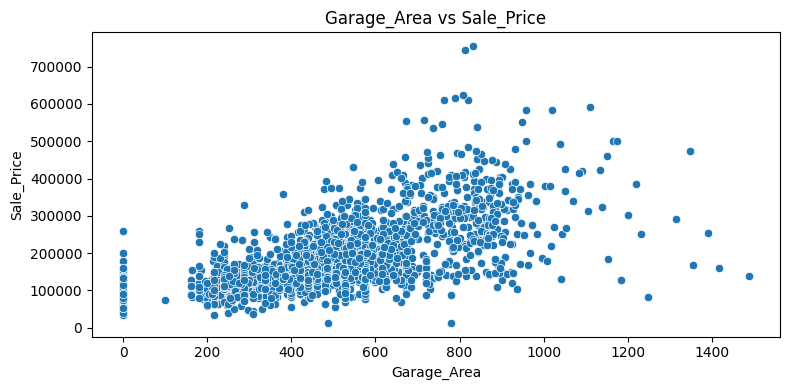

In [12]:
# Scatter plot of Gr_Liv_Area vs Sale_Price
plt.figure(figsize=(8, 4))
sns.scatterplot(x='Garage_Area', y='Sale_Price', data=df)
plt.title('Garage_Area vs Sale_Price')
plt.xlabel('Garage_Area')
plt.ylabel('Sale_Price')
plt.tight_layout()
plt.show()

In [13]:
# Create a training and test set with a 75:25 split ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [14]:
# Build a multiple linear regression model using 'Gr_Liv_Area' and 'Garage_Area'
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
# Print the trained model's intercept and coefficients
print('Intercept:', model.intercept_)
print('Coefficients:', model.coef_)

Intercept: -5059.448195610428
Coefficients: [ 78.69286848 141.14571761]


In [17]:
# Generate predictions for the test set
y_pred = model.predict(X_test)


In [19]:
# Evaluate the model's performance by computing the mean squared error (MSE) or root mean squared error (RMSE) on the test set using sklearn.metrics.
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.4f}')

MSE: 2634371879.69
RMSE: 51326.13
R²: 0.6386


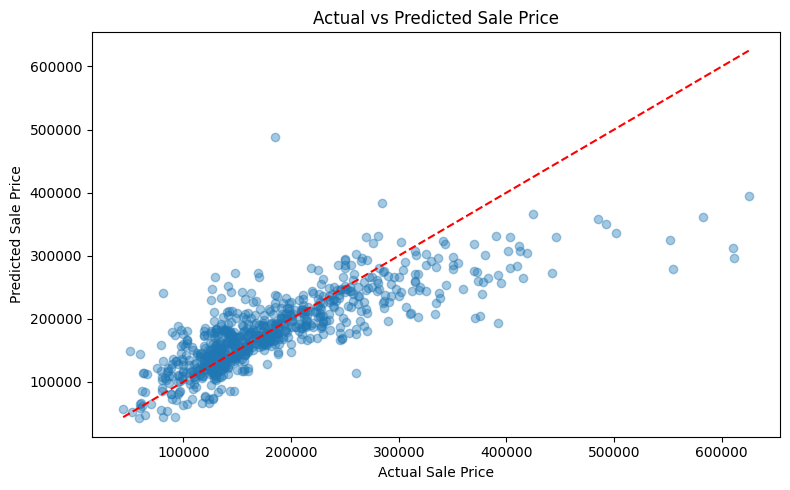

In [20]:
# Generate an error plot to visualise the differences between the predicted and actual values in the test set.
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted Sale Price')
plt.tight_layout()
plt.show()

In [21]:
# Print the coefficients and interpret them within the context of the median value prediction.
print(f'Gr_Liv_Area coefficient: {model.coef_[0]:.2f}')
print(f'Garage_Area coefficient: {model.coef_[1]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')

Gr_Liv_Area coefficient: 78.69
Garage_Area coefficient: 141.15
Intercept: -5059.45


**Interpret coefficients in the context of the prediction:**
Sale_Price = -5059.45 + (78.69 × Gr_Liv_Area) + (141.15 × Garage_Area)

Each extra square foot of living area adds roughly $78.69 to the predicted
price, with garage size held constant. Each extra square foot of garage
adds $141.15, with living area held constant. Garage space has a higher
per-square-foot impact, though living area is the stronger overall
predictor given its larger range. The intercept (-5059.45) is a
mathematical baseline with no real-world meaning.

**Summarise findings**
House prices in the dataset are right-skewed — most sales fall between
$100,000 and $200,000, with a long tail of higher-value properties.
Living area and garage size both showed solid positive correlations with
sale price (0.71 and 0.64 respectively).

The two-variable model got an R² of 0.64 on the test set and an RMSE of
around $51,000. It predicts mid-range prices fairly well but consistently
underestimates higher-end properties, as seen in the error plot. Adding
variables like overall quality rating or year built would likely close
that gap.

# Optional challenge - extended model with additional predictors

In [22]:
# Define extended feature set
X_extended = df[['Gr_Liv_Area', 'Garage_Area', 'First_Flr_SF', 'Year_Built', 'Total_Bsmt_SF']]


In [23]:
# Split into training and test sets
X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(X_extended, y, test_size=0.25, random_state=42)

In [24]:
# Fit the extended linear regression model
model_ext = LinearRegression()
model_ext.fit(X_train_ext, y_train_ext)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
# Print intercept and coefficients for the extended model
print(f'Intercept: {model_ext.intercept_:.2f}')
for feature, coef in zip(X_extended.columns, model_ext.coef_):
    print(f'{feature}: {coef:.2f}')

Intercept: -1432449.63
Gr_Liv_Area: 69.86
Garage_Area: 66.89
First_Flr_SF: 2.37
Year_Built: 728.44
Total_Bsmt_SF: 35.59


In [27]:
# Generate predictions for the test set
y_pred_ext = model_ext.predict(X_test_ext)

In [29]:
# Evaluate extended model performance - RMSE and R²
mse_ext = mean_squared_error(y_test_ext, y_pred_ext)
rmse_ext = np.sqrt(mse_ext)
r2_ext = r2_score(y_test_ext, y_pred_ext)
print(f'Extended Model MSE: {mse_ext:.2f}')
print(f'Extended Model RMSE: {rmse_ext:.2f}')
print(f'Extended Model R²: {r2_ext:.4f}')

Extended Model MSE: 1782563730.99
Extended Model RMSE: 42220.42
Extended Model R²: 0.7555


In [30]:
# Compare extended model against the base model
print('Model Comparison')
print('-' * 35)
print(f'{"Metric":<12} {"Base":>10} {"Extended":>10}')
print('-' * 35)
print(f'{"RMSE":<12} {51326.13:>10.2f} {rmse_ext:>10.2f}')
print(f'{"R²":<12} {0.6386:>10.4f} {r2_ext:>10.4f}')
print('-' * 35)

Model Comparison
-----------------------------------
Metric             Base   Extended
-----------------------------------
RMSE           51326.13   42220.42
R²               0.6386     0.7555
-----------------------------------


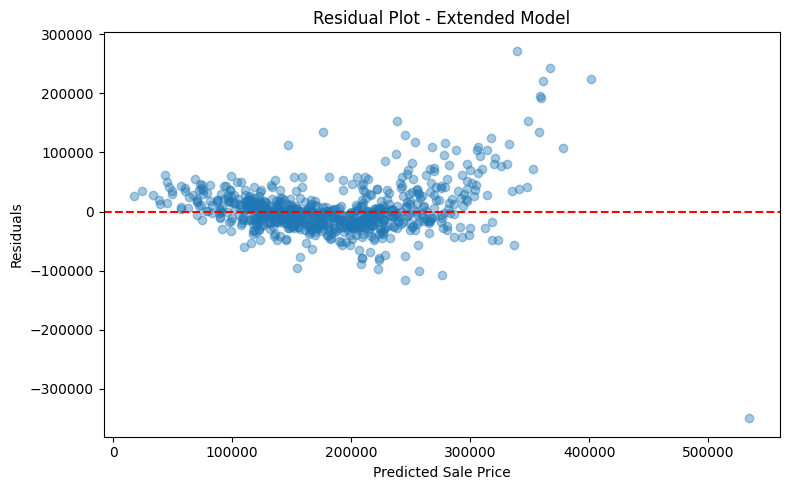

In [31]:
# Residual plot for the extended model
residuals = y_test_ext - y_pred_ext

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_ext, residuals, alpha=0.4)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Sale Price')
plt.ylabel('Residuals')
plt.title('Residual Plot - Extended Model')
plt.tight_layout()
plt.show()